# Do higher-poverty countries receive more Kiva loans per capita? Evidence by poverty tercile and financial access
ECO225 – Project 1
Kexing Yan  
Professor Khazra
Date: 2026-2-4


## 1. Introduction

Kiva is an online microfinance platform that connects individual lenders to borrowers through local partner institutions (e.g., microfinance institutions and NGOs). In this project, I treat **Kiva lending activity as a proxy for microcredit intensity at the country level**, while recognizing that it captures only the markets where Kiva and its partners operate. My main outcomes (Y) are **loans per capita** and **loan amount per capita**, which summarize how intensively Kiva lends in each country relative to population size. These per-capita measures help make cross-country comparisons meaningful because countries differ greatly in population.

A key empirical feature of Kiva data is that many countries have **zero observed loans**. In most cases, a zero does not necessarily mean “no demand for microcredit”; it can also reflect that **Kiva does not operate** in that country (or that partner coverage is limited). For that reason, I present results both **including zeros** (to describe Kiva’s geographic coverage and concentration) and **conditioning on positive-lending countries** (to describe patterns within markets where Kiva is active).

My research question is descriptive: **how is poverty (X) related to Kiva lending intensity (Y), and how might financial access (Z) condition this relationship?** The key explanatory variables are the poverty rate and poverty terciles. I then introduce a financial access mechanism using World Bank indicators of financial infrastructure and inclusion.

(Background motivation) Microfinance is widely viewed as a tool for expanding credit access among low-income populations, yet outreach can be shaped not only by poverty but also by institutional and financial constraints. Studies of microfinance institutions document a tradeoff between serving poorer clients and maintaining efficiency and profitability, suggesting that reaching the very poorest borrowers can be costly and operationally difficult (Cull, Demirgüç-Kunt, and Morduch, 2007; Hermes, Lensink, and Meesters, 2011). At the same time, industry-level evidence highlights how commercialization and market structure influence where microfinance can scale, implying that financial development may condition outreach (Cull, Demirgüç-Kunt, and Morduch, 2009).


## 2. Data Cleaning/Loading

I use a country-level dataset constructed by merging:
- **Kiva outcomes**: number of loans and total loan amount by country (from Kiva data).
- **Poverty (X)**: a country poverty rate, which I also convert into **poverty terciles** (“Low/Medium/High poverty”).
- **World Bank financial access indicators (Z components)**:
  - bank branches per 100,000 adults,
  - ATMs per 100,000 adults,
  - bank accounts per 1,000 adults (or a closely related account-ownership measure, depending on availability),
  - **private credit (% of GDP)** as an additional measure of financial development.

The merge key is the **ISO3 country code** (sometimes called `country_code` or `iso3`). Conceptually, I keep the Kiva-poverty country list as the base and add World Bank variables via a **left join**, so that Kiva-poverty countries remain in the dataset even if some financial indicators are missing. The final merged analysis file is:
- `outputs/country_master_with_finance.csv`

After loading the merged file below, I (i) ensure variables are numeric, (ii) construct per-capita outcomes, (iii) create poverty terciles, and (iv) construct a median split of the financial access index for heterogeneity plots.


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load country-level master data (Kiva + poverty + finance + institutions)
# -----------------------------
df = pd.read_csv("outputs/country_master_with_finance_and_institutions.csv")
df.columns = df.columns.str.strip()

# Core columns we expect for Project 2 (coerce to numeric; keep missing explicitly)
num_cols = [
    "population",
    "n_loans",
    "total_loan_amount",
    "poverty_rate",
    "institutional_pca1",
    "institutional_index",
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------
# Outcomes (Y): per-capita lending intensity + log transform
# -----------------------------
df.loc[df["population"] <= 0, "population"] = np.nan
df["loans_per_capita"] = df["n_loans"] / df["population"]
df["loan_amount_per_capita"] = df["total_loan_amount"] / df["population"]

# Main outcome used in Project 1/2: log loans per capita
# Use log(1 + x) to keep zeros; keeps sample transparent.
df["log_lpc"] = np.log1p(df["loans_per_capita"])

# -----------------------------
# Key regressors (X): poverty (level + quadratic + terciles)
# -----------------------------
df["poverty_rate_sq"] = df["poverty_rate"] ** 2

df["poverty_tercile"] = pd.NA
m_pov = df["poverty_rate"].notna()
df.loc[m_pov, "poverty_tercile"] = pd.qcut(
    df.loc[m_pov, "poverty_rate"],
    q=3,
    labels=["Low poverty", "Medium poverty", "High poverty"],
)

# -----------------------------
# Mechanism (Z): institutional quality (main = PCA1; alt = standardized average)
# -----------------------------
# Keep both; PCA1 is the main Z for Project 2
df["Z_inst"] = df["institutional_pca1"]
df["Z_inst_alt"] = df["institutional_index"]

# Median split for plots (high vs low institutions) — for interaction-style visuals later
df["Z_split"] = pd.NA
z = pd.to_numeric(df["Z_inst"], errors="coerce")
z_med = z.median(skipna=True)
m_z = z.notna()
df.loc[m_z & (z >= z_med), "Z_split"] = "High institutions"
df.loc[m_z & (z <  z_med), "Z_split"] = "Low institutions"

# -----------------------------
# Explicit analysis sample flag (do NOT silently drop rows)
# -----------------------------
required_for_core = ["log_lpc", "poverty_rate", "Z_inst"]
df["sample_core"] = df[required_for_core].notna().all(axis=1)

df.head()

,country_code,n_loans,total_loan_amount,population,population_below_poverty_line,poverty_rate,iso3,urban_rural_gap,atms_per_100k,bank_accounts_per_1000,...,institutional_pca1,loans_per_capita,loan_amount_per_capita,log_lpc,poverty_rate_sq,poverty_tercile,Z_inst,Z_inst_alt,Z_split,sample_core
0,AF,2337,1967950.0,35530081.0,35.8,0.358,AFG,0.215,1.626189,178.793210,...,-2.080862,0.000066,0.055388,0.000066,0.128164,Medium poverty,-2.080862,-1.808621,Low institutions,True
1,AL,3075,4307350.0,2930187.0,14.3,0.143,ALB,0.004,30.683033,1093.310033,...,0.495336,0.001049,1.469992,0.001049,0.020449,Low poverty,0.495336,0.418917,High institutions,True
2,AM,13952,22950475.0,2930450.0,32.0,0.320,ARM,0.000,65.058099,NaN,...,0.270516,0.004761,7.831724,0.004750,0.102400,Medium poverty,0.270516,0.262495,High institutions,True
3,AZ,10172,14784625.0,9827589.0,4.9,0.049,AZE,0.026,34.150007,NaN,...,-0.015080,0.001035,1.504400,0.001035,0.002401,Low poverty,-0.015080,0.014659,High institutions,True
4,BA,608,477250.0,3507017.0,17.2,0.172,BIH,0.000,57.571467,NaN,...,0.043444,0.000173,0.136084,0.000173,0.029584,Low poverty,0.043444,0.029664,High institutions,True


I focus on two country-level outcomes (Y) and a small set of explanatory variables motivated by the mechanism.

- **Outcomes (Y)**:
  - `loans_per_capita` = number of Kiva loans divided by population
  - `loan_amount_per_capita` = total Kiva loan amount divided by population  
  These variables proxy **country-level Kiva lending intensity**, while acknowledging that Kiva activity is only observed where Kiva operates.

- **Main explanatory variable (X)**:
  - `poverty_rate` (and the derived `poverty_tercile` groups)

- **Mechanism / conditioning variable (Z): financial access**
  I construct `financial_access_index` from three World Bank indicators: bank branches per 100k, ATMs per 100k, and bank accounts per 1000.

  **Index construction (transparent steps):**
  1. For each component (bank branches per 100k adults, ATMs per 100k adults, and bank accounts per 1,000 adults), compute a z-score across countries:

     z = (value − sample mean) / sample standard deviation

  2. For each country, compute the financial_access_index as the average of the available component z-scores.

     In code, this is a “skip-missing mean” (skipna=True): if a country is missing one component, we average the remaining ones.

If a country is missing all three components, the index is missing.
- **Additional World Bank variable: private credit**
  `credit_private_gdp` (private sector credit as a percent of GDP) measures **financial depth / financial development**—how large private credit markets are relative to the economy. I report it in summary statistics because it provides complementary information beyond access infrastructure (branches/ATMs/accounts), even if it is not included as a component of the access index.


## 3. Summary Statistics Tables

This section reports summary statistics for the outcome variable (loans per capita) and the explanatory variables. I first report overall summary statistics, then provide subgroup summaries by poverty tercile to examine whether high-poverty countries differ systematically in Kiva lending outcomes and in the proposed mechanism variables.

,Variable,Mean,SD,Min,Median,Max,N
0,Loans per capita,0.0019,0.0088,0.0000,0.0002,0.0837,91
1,Loan amount per capita,1.7503,6.6276,0.0003,0.2583,62.1675,91
2,Poverty rate,0.3235,0.1766,0.0330,0.2955,0.7230,86
3,Institutional quality (PCA1),-0.0000,1.0054,-2.5513,-0.0151,2.6265,93
4,Institutional quality (avg z-score),-0.0000,0.9089,-2.3246,-0.0374,2.4555,93
5,Financial access index (context),0.0803,1.0661,-0.9452,-0.1276,6.8608,83
6,Private credit (% GDP),44.0471,37.1609,1.7184,31.6219,196.0417,84


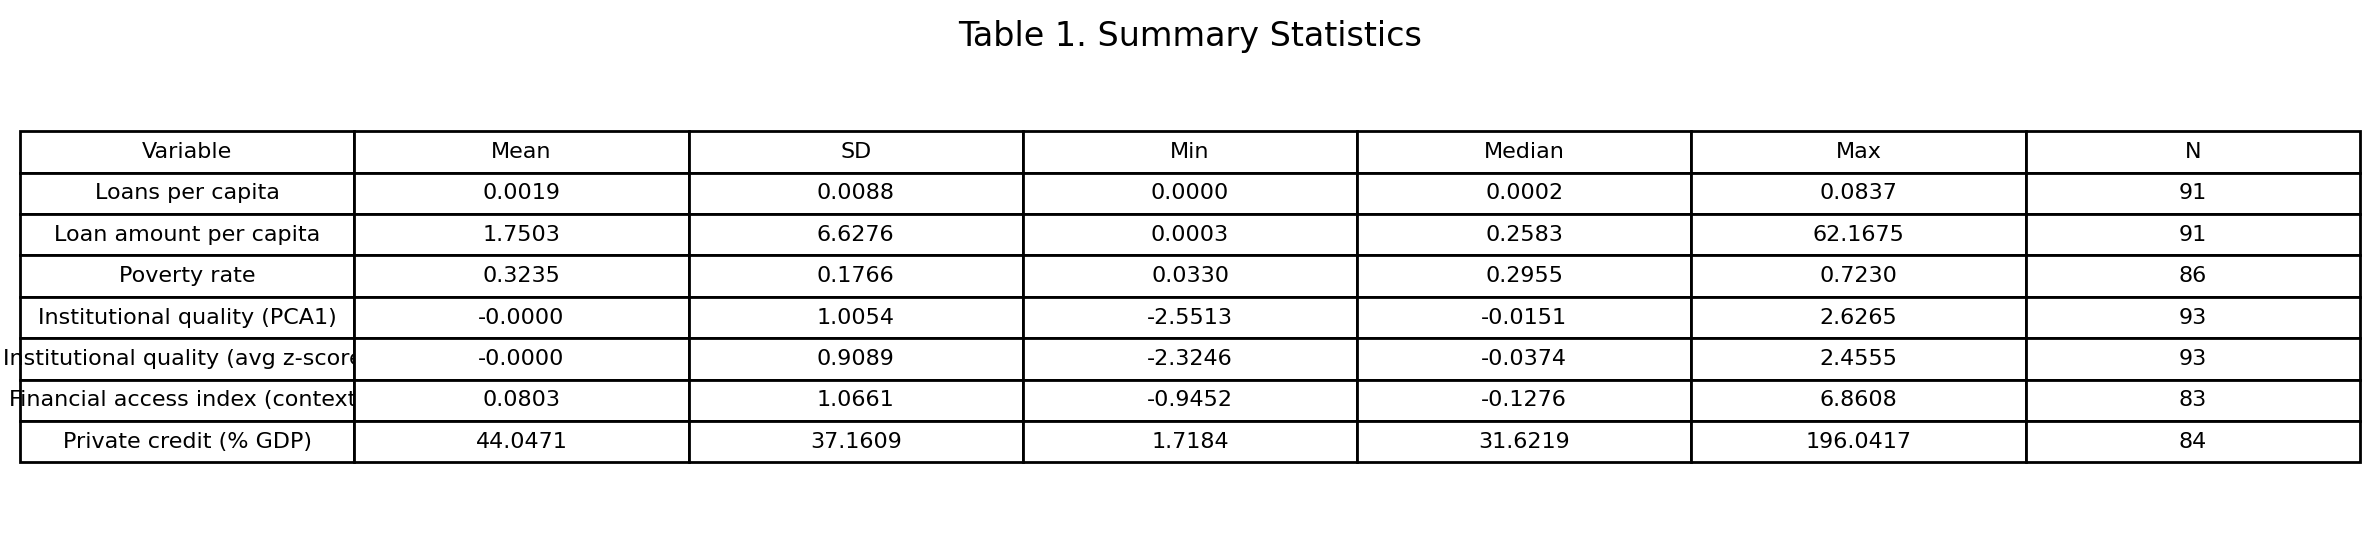

In [72]:
# Table 1. Summary Statistics (country level)

# For Project 2, update Z to institutional quality.
# Keep financial access variables only as optional context (they may be missing).

table1_vars = [
    ("loans_per_capita", "Loans per capita"),
    ("loan_amount_per_capita", "Loan amount per capita"),
    ("poverty_rate", "Poverty rate"),
    ("institutional_pca1", "Institutional quality (PCA1)"),
    ("institutional_index", "Institutional quality (avg z-score)"),
    # Optional context controls (include only if present)
    ("financial_access_index", "Financial access index (context)"),
    ("credit_private_gdp", "Private credit (% GDP)"),
]

# Ensure numeric; if a variable is missing, create it as all-missing (keeps table reproducible)
for v, _ in table1_vars:
    if v in df.columns:
        df[v] = pd.to_numeric(df[v], errors="coerce")
    else:
        df[v] = np.nan

rows = []
for v, label in table1_vars:
    s = df[v].dropna()
    rows.append({
        "Variable": label,
        "Mean": s.mean() if len(s) else np.nan,
        "SD": s.std() if len(s) > 1 else np.nan,
        "Min": s.min() if len(s) else np.nan,
        "Median": s.median() if len(s) else np.nan,
        "Max": s.max() if len(s) else np.nan,
        "N": int(len(s)),
    })

table1 = pd.DataFrame(rows)

# Format for display
table1_display = table1.copy()
for c in ["Mean", "SD", "Min", "Median", "Max"]:
    table1_display[c] = table1_display[c].map(lambda x: "" if pd.isna(x) else f"{x:.4f}")
table1_display["N"] = table1_display["N"].astype(int)

display(table1_display)

# Render as a figure so it survives PDF export
fig, ax = plt.subplots(figsize=(12, 2.8), dpi=200)
ax.axis("off")
tbl = ax.table(
    cellText=table1_display.values,
    colLabels=table1_display.columns,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.2)
plt.title("Table 1. Summary Statistics", pad=10)
plt.tight_layout()
plt.show()

**Interpretation (Table 1).**  
Table 1 summarizes the main variables at the country level. The lending outcomes are highly concentrated: many countries have very small `loans_per_capita`, while a smaller set of countries have much higher values, which is consistent with Kiva operating in a limited set of markets. The financial access index varies substantially across countries, indicating large differences in financial infrastructure and inclusion. Poverty rates also span a wide range, which makes tercile comparisons informative. Finally, private credit (% of GDP) provides an additional view of financial development (depth), which may differ from “access” measured by branches/ATMs/accounts.


,poverty_tercile,mean_loans_per_capita,mean_loan_amount_per_capita,mean_institutional_pca1,share_positive_loans,N
0,High poverty,0.0008,0.7394,-0.5694,1.0000,29
1,Low poverty,0.0008,0.9397,0.6538,1.0000,29
2,Medium poverty,0.0016,1.5145,-0.3292,1.0000,28


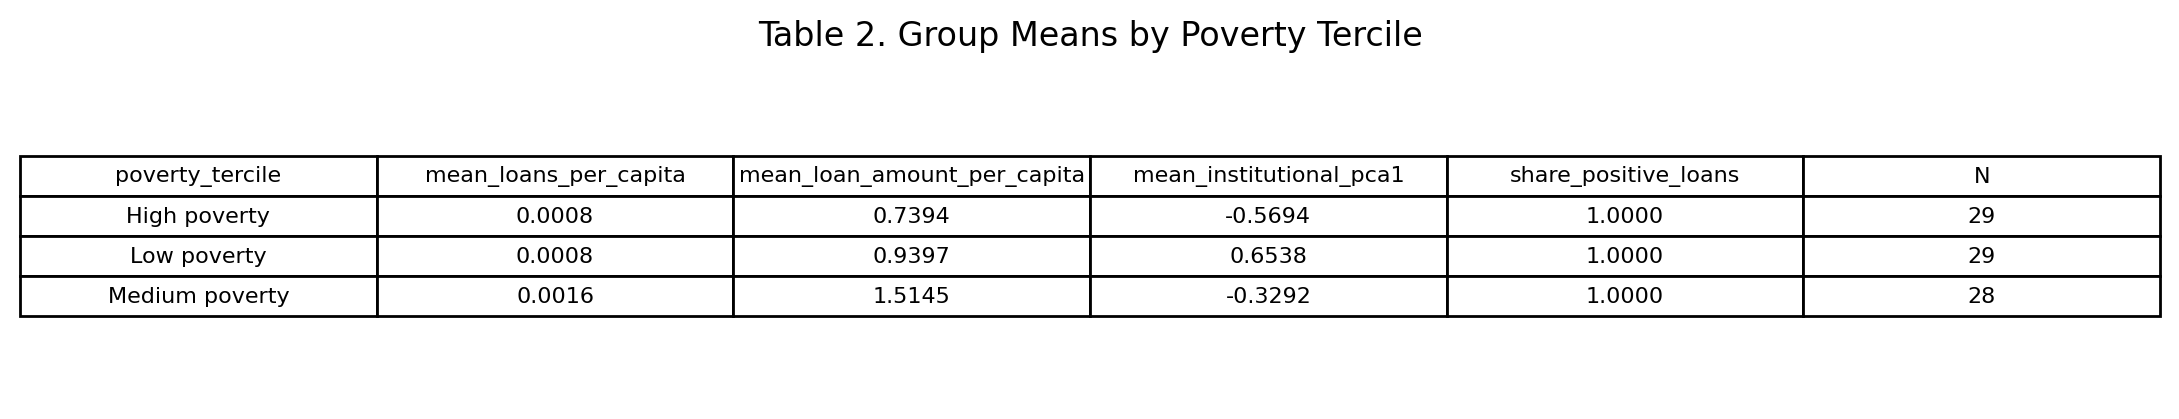

In [73]:
# Table 2. Group Means by Poverty Tercile (Project 2 version)

# Update mechanism variable to institutional quality
table2_vars = [
    "loans_per_capita",
    "loan_amount_per_capita",
    "institutional_pca1",
]

for v in table2_vars:
    if v in df.columns:
        df[v] = pd.to_numeric(df[v], errors="coerce")
    else:
        df[v] = np.nan

# Keep observations with defined poverty tercile
df_g = df.dropna(subset=["poverty_tercile"]).copy()

# Indicator for any Kiva activity
df_g["positive_loans"] = (
    pd.to_numeric(df_g["loans_per_capita"], errors="coerce") > 0
).astype(int)

group_table = (
    df_g.groupby("poverty_tercile", observed=False)
        .agg(
            mean_loans_per_capita=("loans_per_capita", "mean"),
            mean_loan_amount_per_capita=("loan_amount_per_capita", "mean"),
            mean_institutional_pca1=("institutional_pca1", "mean"),
            share_positive_loans=("positive_loans", "mean"),
            N=("poverty_tercile", "size"),
        )
        .reset_index()
)

group_table_display = group_table.copy()
for c in [
    "mean_loans_per_capita",
    "mean_loan_amount_per_capita",
    "mean_institutional_pca1",
    "share_positive_loans",
]:
    group_table_display[c] = group_table_display[c].map(
        lambda x: "" if pd.isna(x) else f"{x:.4f}"
    )
group_table_display["N"] = group_table_display["N"].astype(int)

display(group_table_display)

# Render as a figure so it survives PDF export
fig, ax = plt.subplots(figsize=(11, 2.2), dpi=200)
ax.axis("off")
tbl = ax.table(
    cellText=group_table_display.values,
    colLabels=group_table_display.columns,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.25)
plt.title("Table 2. Group Means by Poverty Tercile", pad=10)
plt.tight_layout()
plt.show()

**Interpretation (Table 2).**  
Table 2 compares average outcomes across poverty terciles. The pattern is non-monotonic: the **medium-poverty** group has the highest mean lending intensity, while both low- and high-poverty groups have lower average lending. The table also reports the share of countries with positive lending within each tercile, helping separate “coverage” (whether Kiva operates) from “intensity” (how much lending occurs where it operates). The financial access index differs across terciles as well, which motivates looking at heterogeneity by financial access in later figures.


## 4. Plots and Interpretation

In this section I use multiple chart types to (i) show the strong concentration of lending, (ii) document how lending varies with poverty, (iii) separate **coverage (zeros)** from **intensity (positive lending)**, and (iv) provide a simple geographic breakdown of where Kiva lending is observed.


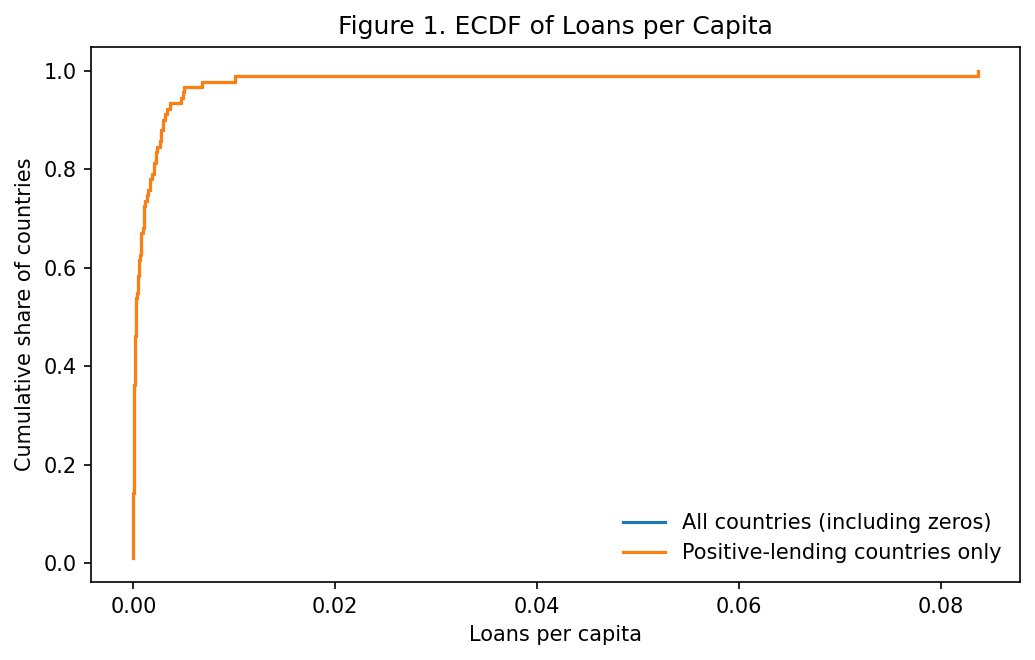

Share of countries with zero observed loans_per_capita: 0.000


In [74]:
# Figure 1. Empirical CDF of loans per capita
# (Full sample vs positive-lending countries)
# Standardized size for all main figures in the paper

FIGSIZE = (7, 4.5)   # <- use this same size for all four main figures
DPI = 150

y_all = pd.to_numeric(df["loans_per_capita"], errors="coerce").dropna()
y_pos = y_all[y_all > 0]

def ecdf(arr):
    a = np.sort(arr)
    p = np.arange(1, len(a) + 1) / len(a)
    return a, p

x_all, p_all = ecdf(y_all.values) if len(y_all) else (np.array([]), np.array([]))
x_pos, p_pos = ecdf(y_pos.values) if len(y_pos) else (np.array([]), np.array([]))

plt.figure(figsize=FIGSIZE, dpi=DPI)

if len(x_all):
    plt.step(x_all, p_all, where="post", label="All countries (including zeros)")
if len(x_pos):
    plt.step(x_pos, p_pos, where="post", label="Positive-lending countries only")

plt.title("Figure 1. ECDF of Loans per Capita")
plt.xlabel("Loans per capita")
plt.ylabel("Cumulative share of countries")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Explicitly report the mass at zero
mass_zero = float((y_all == 0).mean()) if len(y_all) else np.nan
print(f"Share of countries with zero observed loans_per_capita: {mass_zero:.3f}")

**Figure 1 interpretation.**  
Figure 1 shows a strong concentration of Kiva lending across countries. The ECDF rises sharply near zero, indicating that a large fraction of countries have extremely small lending intensity. The printed “mass at zero” makes this explicit: many countries have **zero observed loans**, which likely reflects that Kiva does not operate everywhere. When conditioning on positive-lending countries, the ECDF shifts to the right, highlighting that “intensity” patterns can look different once we restrict attention to Kiva’s active markets. This motivates reporting results both with and without zeros.


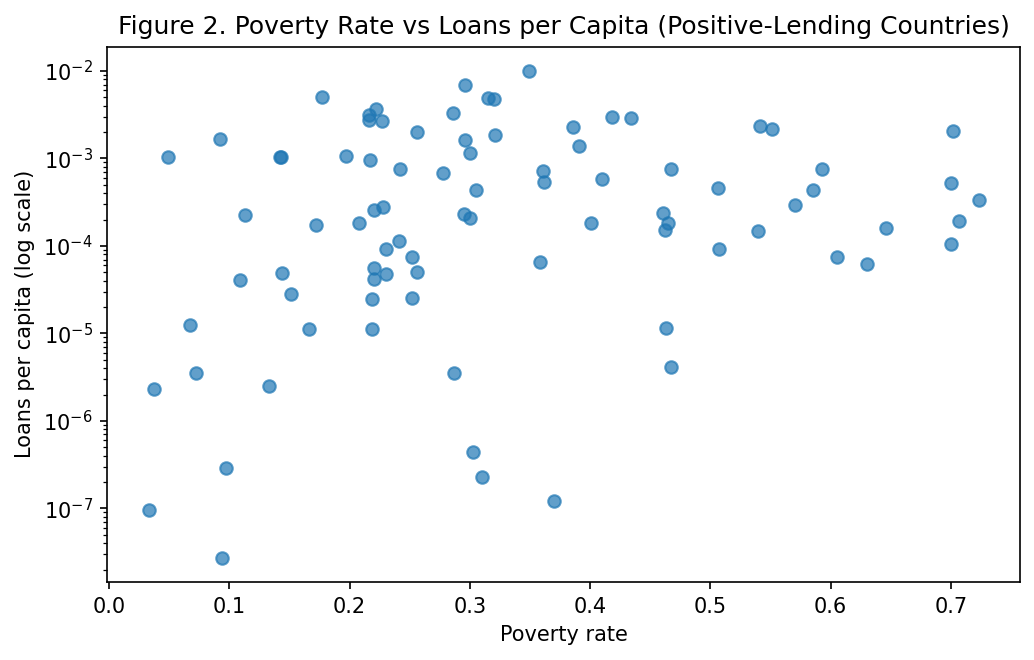

In [75]:
# Figure 2. Poverty Rate vs Loans per Capita (Positive-Lending Countries)
# Use standardized figure size for consistency across all four main figures

FIGSIZE = (7, 4.5)
DPI = 150

df2 = df.copy()
df2["poverty_rate"] = pd.to_numeric(df2["poverty_rate"], errors="coerce")
df2["loans_per_capita"] = pd.to_numeric(df2["loans_per_capita"], errors="coerce")

# Keep observations with defined poverty and positive lending
df2_pos = df2.dropna(subset=["poverty_rate", "loans_per_capita"]).copy()
df2_pos = df2_pos[df2_pos["loans_per_capita"] > 0]

plt.figure(figsize=FIGSIZE, dpi=DPI)

plt.scatter(
    df2_pos["poverty_rate"],
    df2_pos["loans_per_capita"],
    alpha=0.7
)

plt.yscale("log")

plt.title("Figure 2. Poverty Rate vs Loans per Capita (Positive-Lending Countries)")
plt.xlabel("Poverty rate")
plt.ylabel("Loans per capita (log scale)")
plt.tight_layout()
plt.show()

**Figure 2 interpretation.**  
Figure 2 focuses on countries where Kiva lending is observed (loans per capita > 0) and uses a log scale because lending intensity is highly skewed. The relationship between poverty and lending intensity is not strongly monotonic: very poor countries are not always the highest recipients of Kiva lending per capita. One plausible explanation is that reaching extremely poor environments can be operationally difficult (higher costs, weaker institutions, limited partner capacity), so lending may concentrate where both need and delivery capacity are present. This motivates the role of financial access (Z) as a conditioning factor.


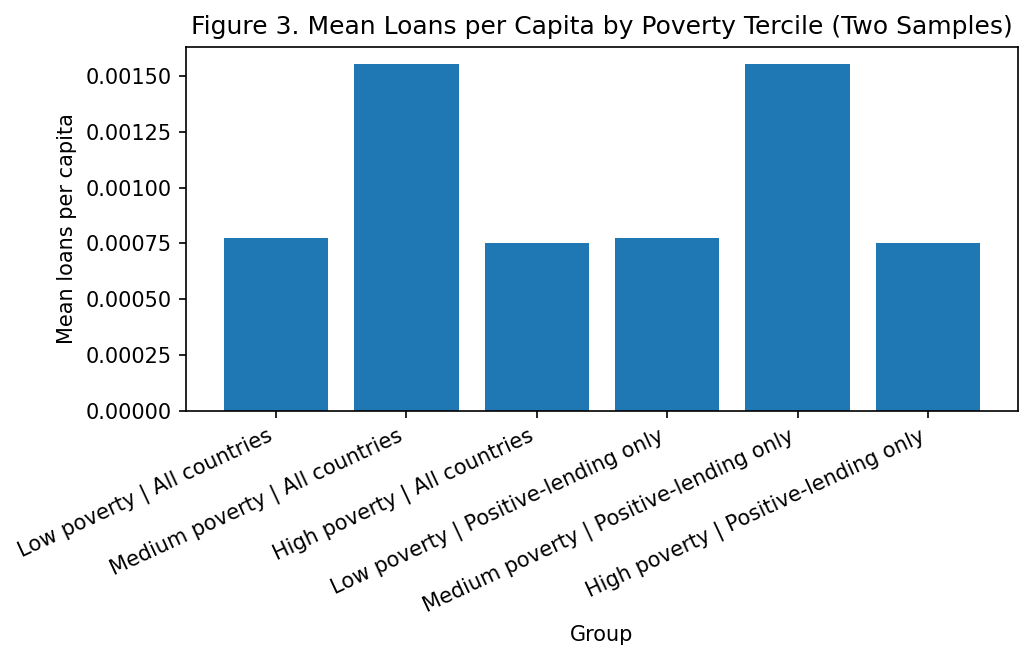

In [76]:
# Figure 3. Mean Loans per Capita by Poverty Tercile (Two Samples)
# Standardized figure size for consistency

FIGSIZE = (7, 4.5)
DPI = 150

df3 = df.copy()
df3["loans_per_capita"] = pd.to_numeric(df3["loans_per_capita"], errors="coerce")

# Ensure poverty tercile has a consistent order
tercile_order = ["Low poverty", "Medium poverty", "High poverty"]
df3["poverty_tercile"] = pd.Categorical(
    df3["poverty_tercile"],
    categories=tercile_order,
    ordered=True
)

g_all = (
    df3.dropna(subset=["poverty_tercile", "loans_per_capita"])
       .groupby("poverty_tercile", observed=False)["loans_per_capita"]
       .mean()
)

g_pos = (
    df3.dropna(subset=["poverty_tercile", "loans_per_capita"])
       .query("loans_per_capita > 0")
       .groupby("poverty_tercile", observed=False)["loans_per_capita"]
       .mean()
)

plot_df = pd.DataFrame({
    "All countries": g_all,
    "Positive-lending only": g_pos
}).reset_index()

plot_df_melt = plot_df.melt(
    id_vars="poverty_tercile",
    var_name="Sample",
    value_name="Mean loans per capita"
)

plt.figure(figsize=FIGSIZE, dpi=DPI)

x_labels = []
values = []

for _, row in plot_df_melt.iterrows():
    label = f"{row['poverty_tercile']} | {row['Sample']}"
    x_labels.append(label)
    values.append(row["Mean loans per capita"])

plt.bar(x_labels, values)

plt.title("Figure 3. Mean Loans per Capita by Poverty Tercile (Two Samples)")
plt.xlabel("Group")
plt.ylabel("Mean loans per capita")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


**Figure 3 interpretation.**  
Figure 3 summarizes the tercile pattern in two ways. Using the full sample (including zeros), the medium-poverty tercile has the highest average lending intensity, which partly reflects where Kiva chooses to operate. Restricting to positive-lending countries reduces the mechanical effect of zeros, but the non-monotonic pattern can still persist if Kiva concentrates more intensely in certain middle-poverty markets. A reasonable hypothesis is that medium-poverty countries combine substantial credit need with sufficient partner/institutional capacity to scale lending. This again suggests that poverty alone is not enough to explain where microcredit activity is concentrated.


Z_split,High institutions,Low institutions
poverty_tercile,,
Low poverty,0.000545,0.002199
Medium poverty,0.002380,0.001233
High poverty,0.000568,0.000802


Z_split,High institutions,Low institutions
poverty_tercile,,
Low poverty,25,4
Medium poverty,9,17
High poverty,6,23


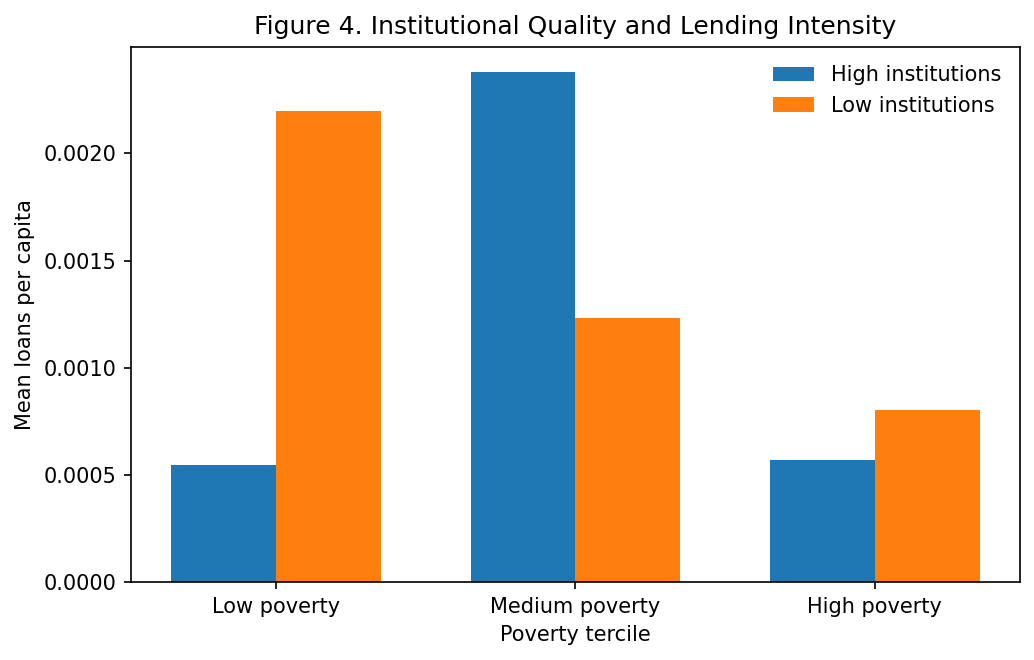

In [77]:
# Figure 4. Heterogeneity by Institutional Quality (Z split) within Poverty Tercile
# Project 2 mechanism: Z = institutional quality (PCA1 median split)

FIGSIZE = (7, 4.5)
DPI = 150

df4 = df.copy()
df4["loans_per_capita"] = pd.to_numeric(df4["loans_per_capita"], errors="coerce")

# Ensure ordered terciles
tercile_order = ["Low poverty", "Medium poverty", "High poverty"]
df4["poverty_tercile"] = pd.Categorical(
    df4["poverty_tercile"],
    categories=tercile_order,
    ordered=True
)

# Focus on positive-lending countries to study lending intensity
df4 = df4.dropna(subset=["poverty_tercile", "Z_split", "loans_per_capita"])
df4_pos = df4[df4["loans_per_capita"] > 0].copy()

# Mean loans per capita by poverty tercile × institutional quality
pivot = df4_pos.pivot_table(
    index="poverty_tercile",
    columns="Z_split",
    values="loans_per_capita",
    aggfunc="mean",
    observed=False
)

display(pivot.round(6))

# Also report group sizes for transparency
counts = df4_pos.pivot_table(
    index="poverty_tercile",
    columns="Z_split",
    values="loans_per_capita",
    aggfunc="size",
    observed=False
)

display(counts)

# ---- Visualization (standardized size) ----
plt.figure(figsize=FIGSIZE, dpi=DPI)

if not pivot.empty:
    x = np.arange(len(pivot.index))
    width = 0.35
    
    cols = pivot.columns.tolist()
    
    for i, col in enumerate(cols):
        plt.bar(
            x + (i - (len(cols)-1)/2) * width,
            pivot[col].values,
            width=width,
            label=col
        )

    plt.xticks(x, pivot.index.astype(str))
    plt.ylabel("Mean loans per capita")
    plt.xlabel("Poverty tercile")
    plt.title("Figure 4. Institutional Quality and Lending Intensity")
    plt.legend(frameon=False)

plt.tight_layout()
plt.show()


**Figure 4 interpretation.**  
Figure 4 introduces financial access as a conditioning factor and focuses on the positive-lending sample to study lending intensity within Kiva’s active markets. In the medium-poverty group, countries with higher financial access tend to have higher lending per capita, consistent with the idea that basic infrastructure (branches/ATMs/accounts) can complement microfinance delivery and scaling. In low-poverty countries, the relationship can be weaker or even negative if formal banking substitutes for microfinance. In high-poverty countries, the difference between high- and low-access groups may be small if constraints other than financial infrastructure (e.g., institutional capacity, partner networks, or instability) dominate. Overall, the figure supports the interpretation that financial access shapes where microfinance can expand, rather than simply increasing lending everywhere.


### Geographic breakdown (where does Kiva lending occur?)

Kiva lending is not globally distributed but instead concentrated in a limited subset of countries. Countries with positive lending activity account for the vast majority of observed loans per capita, while many countries exhibit zero lending. This pattern reflects Kiva’s operational presence rather than differences in underlying credit demand.

The strong concentration of lending activity motivates reporting results both for the full sample and for the subsample of countries with positive lending, allowing a clearer distinction between coverage effects and within-market lending intensity.

In [78]:
# Figure 5. Geographic breakdown (region/continent if available; otherwise show top countries)
# Keep the same size convention for all figures

FIGSIZE = (7, 4.5)
DPI = 150

# Try to find a region-like column already in the merged dataset
candidate_region_cols = [
    "region", "Region", "wb_region", "world_bank_region",
    "continent", "Continent", "subregion"
]
region_col = None
for c in candidate_region_cols:
    if c in df.columns:
        region_col = c
        break

df_geo = df.copy()
df_geo["loans_per_capita"] = pd.to_numeric(df_geo["loans_per_capita"], errors="coerce")
df_geo["positive_loans"] = (df_geo["loans_per_capita"] > 0).astype(int)

if region_col is not None:
    geo = (
        df_geo.dropna(subset=[region_col])
              .groupby(region_col, observed=False)
              .agg(
                  share_positive=("positive_loans", "mean"),
                  mean_loans_pos=("loans_per_capita", lambda s: s[s > 0].mean()),
                  N=("positive_loans", "size")
              )
              .reset_index()
              .sort_values("share_positive", ascending=False)
    )

    display(geo)

    plt.figure(figsize=FIGSIZE, dpi=DPI)
    plt.bar(geo[region_col].astype(str), geo["share_positive"].values)
    plt.title("Figure 5. Share of Countries with Positive Kiva Lending by Region")
    plt.xlabel("Region")
    plt.ylabel("Share with loans_per_capita > 0")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

else:
    # Fallback: list the top countries by lending intensity (descriptive, not geographic)
    cols_wanted = ["country", "country_code", "poverty_tercile", "poverty_rate", "loans_per_capita"]
    cols_exist = [c for c in cols_wanted if c in df_geo.columns]

    top = (
        df_geo.dropna(subset=["loans_per_capita"])
              .sort_values("loans_per_capita", ascending=False)
              .loc[:, cols_exist]
              .head(15)
    )

    display(top)
    print("Note: No region/continent column was found in the merged dataset, so a regional breakdown could not be produced.")

,country_code,poverty_tercile,poverty_rate,loans_per_capita
90,WS,<NA>,NaN,0.083664
74,SV,Medium poverty,0.349,0.010041
57,NI,Medium poverty,0.296,0.006839
40,KH,Low poverty,0.177,0.004980
78,TJ,Medium poverty,0.315,0.004925
2,AM,Medium poverty,0.320,0.004761
66,PY,Low poverty,0.222,0.003639
42,LB,Medium poverty,0.286,0.003302
50,MN,Low poverty,0.216,0.003140
79,TL,High poverty,0.418,0.002944


Note: No region/continent column was found in the merged dataset, so a regional breakdown could not be produced.


In [79]:
# -----------------------------
# Project 2 — Main Regression Analysis
# -----------------------------

import statsmodels.api as sm
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
import os

# ----------------------------------
# 1. Define unified regression sample
# ----------------------------------

reg_vars = [
    "log_lpc",
    "poverty_rate",
    "poverty_rate_sq",
    "institutional_pca1"
]

df_reg = df.copy()

for v in reg_vars:
    if v in df_reg.columns:
        df_reg[v] = pd.to_numeric(df_reg[v], errors="coerce")

df_reg = df_reg.dropna(subset=["log_lpc", "poverty_rate", "institutional_pca1"]).copy()

print("Total countries:", len(df))
print("Regression sample:", len(df_reg))


# ----------------------------------
# 2. Run models (HC1 robust SE)
# ----------------------------------

m1 = smf.ols("log_lpc ~ poverty_rate", data=df_reg).fit(cov_type="HC1")

m2 = smf.ols("log_lpc ~ poverty_rate + poverty_rate_sq", data=df_reg).fit(cov_type="HC1")

m3 = smf.ols("log_lpc ~ poverty_rate + poverty_rate_sq + institutional_pca1",
             data=df_reg).fit(cov_type="HC1")

m4 = smf.ols("log_lpc ~ poverty_rate + poverty_rate_sq + institutional_pca1 \
              + poverty_rate:institutional_pca1",
             data=df_reg).fit(cov_type="HC1")


# ----------------------------------
# 3. Export Stargazer table
# ----------------------------------

os.makedirs("outputs", exist_ok=True)

stargazer = Stargazer([m1, m2, m3, m4])
stargazer.title("Institutional Quality and the Poverty–Microfinance Relationship")
stargazer.custom_columns(["(1)", "(2)", "(3)", "(4)"], [1, 1, 1, 1])
stargazer.significant_digits(3)
stargazer.add_line("Robust SE", ["Yes", "Yes", "Yes", "Yes"])

with open("outputs/regression_main_results.html", "w") as f:
    f.write(stargazer.render_html())

print("Regression table saved to outputs/regression_main_results.html")

Total countries: 96
Regression sample: 84
Regression table saved to outputs/regression_main_results.html


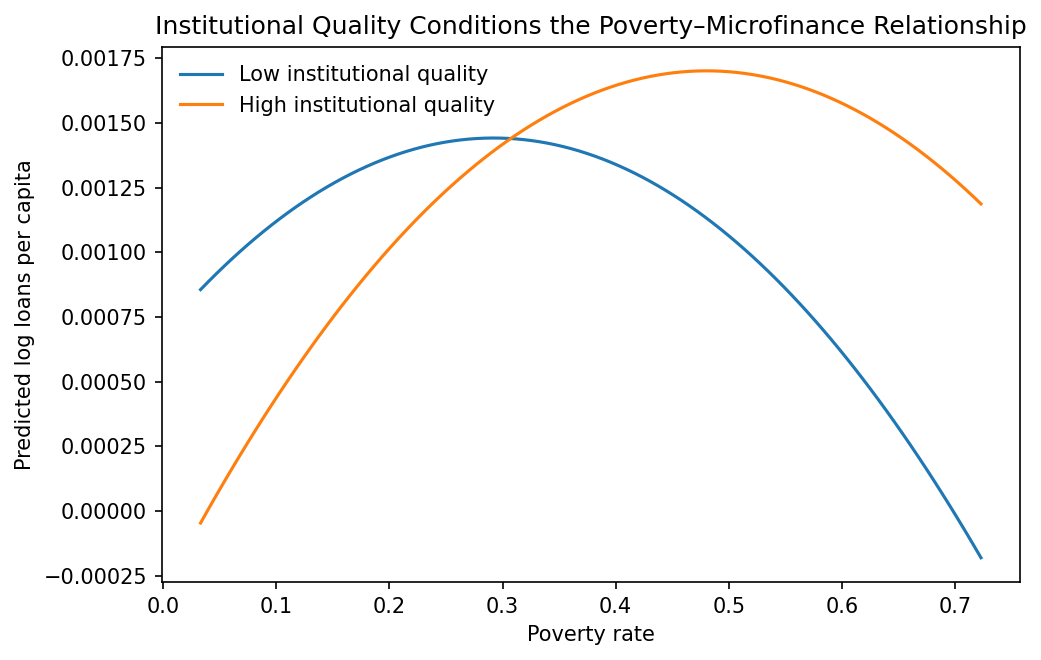

In [80]:
# ----------------------------------------
# Main Message Figure: Predicted Interaction
# ----------------------------------------

import numpy as np

# Create poverty grid
p_grid = np.linspace(df_reg["poverty_rate"].min(),
                     df_reg["poverty_rate"].max(), 100)

# Define high and low institutions (±1 SD)
z_mean = df_reg["institutional_pca1"].mean()
z_sd   = df_reg["institutional_pca1"].std()

z_low  = z_mean - z_sd
z_high = z_mean + z_sd

def predict(p, z):
    return (
        m4.params["Intercept"]
        + m4.params["poverty_rate"] * p
        + m4.params["poverty_rate_sq"] * (p**2)
        + m4.params["institutional_pca1"] * z
        + m4.params["poverty_rate:institutional_pca1"] * (p * z)
    )

y_low  = predict(p_grid, z_low)
y_high = predict(p_grid, z_high)

plt.figure(figsize=(7,4.5), dpi=150)
plt.plot(p_grid, y_low, label="Low institutional quality")
plt.plot(p_grid, y_high, label="High institutional quality")

plt.xlabel("Poverty rate")
plt.ylabel("Predicted log loans per capita")
plt.title("Institutional Quality Conditions the Poverty–Microfinance Relationship")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 5. Conclusion

The descriptive evidence suggests that Kiva lending is **not** concentrated in the very poorest countries. Instead, average lending intensity is highest for countries in the **middle poverty tercile**, and lending patterns vary with **financial access**. In particular, within countries where Kiva is active, higher financial access tends to be associated with higher lending in the medium-poverty group, consistent with the idea that basic financial infrastructure may complement microfinance delivery.

A central limitation is coverage: many countries have **zero observed loans**, which likely reflects where Kiva and partner institutions operate rather than pure lending demand. For that reason, I interpret the results as evidence about **Kiva’s allocation and market presence**, not global microcredit demand across all countries.


In [81]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

from stargazer.stargazer import Stargazer
from IPython.display import HTML, display

DATA_PATH = "outputs/final_panel_country_year.csv"

df = pd.read_csv(DATA_PATH)

# Quick sanity check
print("Rows:", df.shape[0], "Cols:", df.shape[1])
print("Years:", sorted(df["year"].dropna().unique()) if "year" in df.columns else "no year col")

base_vars = [
    "log_total_loan_amount",
    "log_gdp_pc",
    "institutional_pca1",
    "log_population",
    "year",
    "country_code"
]

missing_cols = [c for c in base_vars if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in df: {missing_cols}")

reg = df[base_vars].dropna().copy()
reg["year"] = reg["year"].astype(int)

print("Baseline sample rows:", reg.shape[0])
print("Countries:", reg["country_code"].nunique(), "Years:", reg["year"].nunique())

Rows: 357 Cols: 12
Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]
Baseline sample rows: 348
Countries: 81 Years: 5


In [82]:
def fit_ols(formula, data, se="HC1", cluster_col=None):
    """
    se:
      - "HC1" for heteroskedasticity-robust
      - "cluster" for cluster-robust (requires cluster_col)
    """
    m = smf.ols(formula, data=data).fit()

    if se.upper() == "HC1":
        return m.get_robustcov_results(cov_type="HC1")
    elif se.lower() == "cluster":
        if cluster_col is None:
            raise ValueError("cluster_col must be provided when se='cluster'")
        return m.get_robustcov_results(cov_type="cluster", groups=data[cluster_col])
    else:
        raise ValueError("se must be 'HC1' or 'cluster'")

In [83]:
import pandas as pd
# Your Models 1–4
f1 = "log_total_loan_amount ~ log_gdp_pc"
f2 = "log_total_loan_amount ~ log_gdp_pc + institutional_pca1"
f3 = "log_total_loan_amount ~ log_gdp_pc + institutional_pca1 + log_population"
f4 = "log_total_loan_amount ~ log_gdp_pc * institutional_pca1 + log_population"

m1 = fit_ols(f1, reg, se="HC1")
m2 = fit_ols(f2, reg, se="HC1")
m3 = fit_ols(f3, reg, se="HC1")
m4 = fit_ols(f4, reg, se="HC1")

from statsmodels.iolib.summary2 import summary_col

tbl = summary_col(
    [m1, m2, m3, m4],
    stars=True,
    model_names=["(1)", "(2)", "(3)", "(4)"],
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.3f}"
    }
)

print(tbl)


                                 (1)        (2)        (3)        (4)    
-------------------------------------------------------------------------
Intercept                     13.4346*** 14.1660*** 12.2128*** 11.8249***
                              (0.7764)   (0.9270)   (1.3451)   (1.4203)  
log_gdp_pc                    -0.0548    -0.1449    -0.1805    -0.1369   
                              (0.1000)   (0.1184)   (0.1179)   (0.1192)  
institutional_pca1                       0.1893     0.2512*    1.9981**  
                                         (0.1450)   (0.1484)   (0.8017)  
log_population                                      0.1344**   0.1443**  
                                                    (0.0655)   (0.0674)  
log_gdp_pc:institutional_pca1                                  -0.2267** 
                                                               (0.1061)  
R-squared                     0.0009     0.0059     0.0182     0.0364    
R-squared Adj.                -0.0019

In [84]:
# (A) Quadratic in log_gdp_pc (nonlinearity / middle-income story)
import numpy as np
from statsmodels.iolib.summary2 import summary_col
from IPython.display import HTML, display

# -----------------------
# (5) Quadratic GDP
# -----------------------
reg = reg.copy()
reg["log_gdp_pc_sq"] = reg["log_gdp_pc"] ** 2

f5 = "log_total_loan_amount ~ log_gdp_pc + log_gdp_pc_sq + institutional_pca1 + log_population"
m5 = fit_ols(f5, reg, se="HC1")

# -----------------------
# (6) Year FE
# -----------------------
f6 = "log_total_loan_amount ~ log_gdp_pc + institutional_pca1 + log_population + C(year)"
m6 = fit_ols(f6, reg, se="HC1")

models_extra = [m5, m6]
names_extra = ["(5) Quad GDP", "(6) + Year FE"]

# -----------------------
# (7)-(8) Alternative Z: institutional_index
# -----------------------
need_cols_7 = ["log_total_loan_amount", "log_gdp_pc", "institutional_index", "log_population", "year", "country_code"]
if all(c in df.columns for c in need_cols_7):
    reg2 = df[need_cols_7].dropna().copy()
    reg2["year"] = reg2["year"].astype(int)

    f7 = "log_total_loan_amount ~ log_gdp_pc + institutional_index + log_population"
    f8 = "log_total_loan_amount ~ log_gdp_pc * institutional_index + log_population"

    m7 = fit_ols(f7, reg2, se="HC1")
    m8 = fit_ols(f8, reg2, se="HC1")

    models_extra += [m7, m8]
    names_extra += ["(7) inst_index", "(8) inst_index x GDP"]
else:
    print("Skip (7)-(8): institutional_index block missing some columns:", [c for c in need_cols_7 if c not in df.columns])

# -----------------------
# (9)-(10) Alternative Z: financial_access_index
# -----------------------
need_cols_9 = ["log_total_loan_amount", "log_gdp_pc", "financial_access_index", "log_population", "year", "country_code"]
if all(c in df.columns for c in need_cols_9):
    reg3 = df[need_cols_9].dropna().copy()
    reg3["year"] = reg3["year"].astype(int)

    f9  = "log_total_loan_amount ~ log_gdp_pc + financial_access_index + log_population"
    f10 = "log_total_loan_amount ~ log_gdp_pc * financial_access_index + log_population"

    m9  = fit_ols(f9, reg3, se="HC1")
    m10 = fit_ols(f10, reg3, se="HC1")

    models_extra += [m9, m10]
    names_extra += ["(9) fin_access", "(10) fin_access x GDP"]
else:
    print("Skip (9)-(10): financial_access_index block missing some columns:", [c for c in need_cols_9 if c not in df.columns])

# -----------------------
# Output table (NO stargazer)
# -----------------------
tbl2 = summary_col(
    models_extra,
    stars=True,
    model_names=names_extra,
    info_dict={
        "N":  lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.3f}"
    }
)

display(HTML(tbl2.as_html()))

,(5) Quad GDP,(6) + Year FE,(7) inst_index,(8) inst_index x GDP,(9) fin_access,(10) fin_access x GDP
Intercept,2.0449,9.8013***,12.3339***,11.8857***,13.1586***,12.9591***
,(4.3847),(1.2096),(1.3638),(1.4357),(1.6718),(1.6996)
log_gdp_pc,2.3154**,-0.1789*,-0.1851,-0.1379,-0.2083,-0.1709
,(1.0897),(0.0950),(0.1205),(0.1218),(0.1507),(0.1612)
log_gdp_pc_sq,-0.1553**,,,,,
,(0.0682),,,,,
institutional_pca1,0.2739*,0.2725**,,,,
,(0.1470),(0.1300),,,,
log_population,0.1538**,0.1453**,0.1292**,0.1414**,0.0918,0.0843
,(0.0668),(0.0605),(0.0647),(0.0667),(0.0645),(0.0659)


In [85]:
from statsmodels.iolib.summary2 import summary_col
from IPython.display import HTML, display

# clustered SE versions of preferred specs
m3_cl = fit_ols(f3, reg, se="cluster", cluster_col="country_code")
m4_cl = fit_ols(f4, reg, se="cluster", cluster_col="country_code")

tbl3 = summary_col(
    [m3_cl, m4_cl],
    stars=True,
    model_names=["(3) Cluster", "(4) Cluster"],
    info_dict={
        "N":  lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.3f}"
    }
)

display(HTML(tbl3.as_html()))

,(3) Cluster,(4) Cluster
Intercept,12.2128***,11.8249***
,(1.9682),(2.1807)
log_gdp_pc,-0.1805,-0.1369
,(0.1580),(0.1548)
institutional_pca1,0.2512,1.9981
,(0.1885),(1.3544)
log_population,0.1344,0.1443
,(0.0967),(0.1027)
log_gdp_pc:institutional_pca1,,-0.2267
,,(0.1806)
